# Principal Component Analysis Introduction

# Principal Components

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation
from sklearn.decomposition import PCA
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV 
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import make_pipeline

In [3]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "dim_reduction"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [5]:
m = 60
X = np.zeros((m, 3))  # initialize 3D dataset
np.random.seed(42)
angles = (np.random.rand(m) ** 3 + 0.5) * 2 * np.pi  # uneven distribution
X[:, 0], X[:, 1] = np.cos(angles), np.sin(angles) * 0.5  # oval
X += 0.28 * np.random.randn(m, 3)  # add more noise
X = Rotation.from_rotvec([np.pi / 29, -np.pi / 20, np.pi / 4]).apply(X)
X += [0.2, 0, 0.2]  # shift a bit

In [7]:
X_centered = X - X.mean(axis = 0)
U, s, Vt = np.linalg.svd(X_centered)

c1 = Vt[0]
c2 = Vt[1]

#### Note: in principle, the SVD factorization algorithm returns three matrices, U, Σ and V, such that X = UΣV⊺, where U is an m × m matrix, Σ is an m × n matrix, and V is an n × n matrix. But the svd() function returns U, s and V⊺ instead. s is the vector containing all the values on the main diagonal of the top n rows of Σ. Since Σ is full of zeros elsewhere, your can easily reconstruct it from s, like this:

In [12]:
m, n  = X.shape
sigma = np.zeros_like(X_centered)
sigma[:n, :n] = np.diag(s)
assert np.allclose(X_centered, U @ sigma @ Vt)

## Projecting Down to Dimensions

In [15]:
W2 = Vt[:2].T
X2D = X_centered @ W2

## Using Scikit-Learn

In [16]:
pca = PCA(n_components= 2)
X2D = pca.fit_transform(X)

In [17]:
pca.components_

array([[ 0.67857588,  0.70073508,  0.22023881],
       [ 0.72817329, -0.6811147 , -0.07646185]])

## Explained Variance Ratio

In [18]:
pca.explained_variance_ratio_

array([0.7578477 , 0.15186921])

The first dimension explains about 76% of the variance, while the second explains about 15%.

By projecting down to 2D, we lost about 9% of the variance:

In [19]:
1 - pca.explained_variance_ratio_.sum()

0.09028309326742046

## Choosing the Right Number of Dimensions

In [22]:
mnist = fetch_openml('mnist_784', as_frame= False, parser = "auto")
X_train  , y_train = mnist.data[:60_000], mnist.target[60_000:]
X_test  , y_test = mnist.data[:60_000], mnist.target[60_000:]

In [23]:
pca = PCA()
pca.fit(X_train)
cumsum = np.cumsum(pca.explained_variance_ratio_)
d = np.argmax(cumsum >= 0.95) + 1 

In [24]:
d

154

In [25]:
pca = PCA(n_components = 0.95)
X_reduced = pca.fit_transform(X_train)

In [26]:
pca.n_components_

154

In [28]:
pca.explained_variance_ratio_.sum()

0.9501960192613033

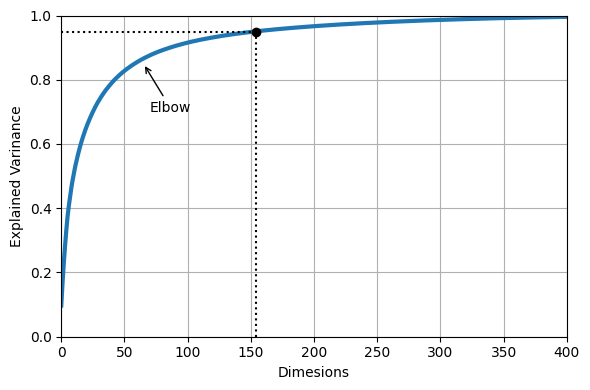

In [32]:
plt.figure(figsize = (6, 4))
plt.plot(cumsum, linewidth = 3)
plt.axis([0, 400, 0, 1])
plt.xlabel("Dimesions")
plt.ylabel("Explained Varinance")
plt.plot([d, d],[0, 0.95], "k:")
plt.plot([0, d], [0.95, 0.95], "k:")
plt.plot(d, 0.95, "ko")
plt.annotate("Elbow", xy = (65, 0.85), xytext = (70, 0.7),
arrowprops = dict(arrowstyle = "->"))
plt.grid(True)
save_fig("explained_variance_plot")

In [36]:
clf = make_pipeline(PCA(random_state= 42),
                   RandomForestClassifier(random_state= 42))

param_distrib = {
    "pca__n_components":  np.arange(10, 80),
    "randomforestclassifier__n_estimators" : np.arange(50, 500)
}

rnd_search = RandomizedSearchCV(clf, param_distrib, n_iter=10, cv = 3, random_state = 42)

rnd_search.fit(X_train[:1000], y_train[:1000])


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('pca', PCA(random_state=42)),
                                             ('randomforestclassifier',
                                              RandomForestClassifier(random_state=42))]),
                   param_distributions={'pca__n_components': array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26,
       27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43,
       44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60,
       6...
       414, 415, 416, 417, 418, 419, 420, 421, 422, 423, 424, 425, 426,
       427, 428, 429, 430, 431, 432, 433, 434, 435, 436, 437, 438, 439,
       440, 441, 442, 443, 444, 445, 446, 447, 448, 449, 450, 451, 452,
       453, 454, 455, 456, 457, 458, 459, 460, 461, 462, 463, 464, 465,
       466, 467, 468, 469, 470, 471, 472, 473, 474, 475, 476, 477, 478,
       479, 480, 481, 482, 483, 484, 485, 486, 487, 488, 489, 490, 491,
       492, 493, 494, 495, 496, 497, 498, 499])},
                   random_state=42)

In [38]:
print(rnd_search.best_params_)

{'randomforestclassifier__n_estimators': 152, 'pca__n_components': 76}


In [40]:
clf = make_pipeline(PCA(random_state= 42), SGDClassifier())
param_gird = {"pca__n_components":np.arange(10, 80)}
grid_search = GridSearchCV(clf, param_gird, cv = 3)
grid_search.fit(X_train[: 1000], y_train[:1000])

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('pca', PCA(random_state=42)),
                                       ('sgdclassifier', SGDClassifier())]),
             param_grid={'pca__n_components': array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26,
       27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43,
       44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60,
       61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77,
       78, 79])})

In [41]:
grid_search.best_params_

{'pca__n_components': 47}